# Education Progress Prediction Model
## Havyn Nonprofit — IS 455 Machine Learning Pipeline

---

## Phase 1 — Business Understanding

### Business Question
**Will a resident show meaningful academic progress over the next 60 days?**

This is a **binary classification** problem:
- `Y = 1` — the resident is likely to make meaningful education progress
- `Y = 0` — the resident is likely to stagnate or decline academically

### Who Cares and Why
Jennifer manages safehouses where every resident is enrolled in some form of education. Aggregate enrollment numbers look fine on paper — but a girl can be enrolled and not progressing. The model identifies girls who are **enrolled but stagnating** before their progress scores plateau — a specific intervention trigger that enrollment headcounts completely miss. In a safehouse of 20 active residents, this model surfaces approximately the 3-5 girls per month who need additional academic support or attendance intervention before stagnation becomes entrenched.

### Two Modeling Goals
| Goal | Model | Purpose |
|---|---|---|
| **Explanatory** | Logistic Regression | Which features are most associated with education progress? |
| **Predictive** | Best of 6 algorithms, auto-selected by CV AUC | Highest out-of-sample performance for deployment |

### Why This Is a Real Predictive Model
The Y label uses two real recorded fields from `education_records`: `progress_percent` and `attendance_rate`. Both conditions must be met for Y=1 because progress percent can increase artificially when attendance is very low — requiring both ensures genuine engagement. Features come from a 60-day window **before** T. The label comes from a 60-day window **after** T.

### Label Construction Logic
- **Y = 1** if `progress_percent` increased by >= 5 percentage points AND **average** `attendance_rate` >= 0.75 in the label window
- **Y = 0** if either condition fails

**Threshold justification:** 5 points filters noise from meaningful advancement on a 0-100 scale. The 0.75 attendance floor ensures the girl was genuinely present and engaged, not just nominally enrolled.

### CRISP-DM Phases
```
Phase 1: Business Understanding
Phase 2: Data Understanding
Phase 3: Data Preparation (rolling window, feature engineering, leakage check, SelectKBest)
Phase 4: Modeling (dummy baseline + 6 algorithms)
Phase 5: Evaluation (CV comparison table, ROC curves, PR curve, business interpretation)
Phase 6: Deployment
```

---
## Phase 2 — Data Understanding
### 2.1 Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, sys, joblib
from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, precision_score,
    recall_score, f1_score, log_loss, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42

# Locate ml_pipeline.py by walking up from cwd (shared ../ml_pipeline.py or legacy models/health/)
_cwd = Path.cwd().resolve()
_ml_path = None
for _base in [_cwd, *_cwd.parents]:
    for _candidate in (
        _base / 'ml_pipeline.py',
        _base / 'models' / 'health' / 'ml_pipeline.py',
    ):
        if _candidate.exists():
            _ml_path = _candidate
            break
    if _ml_path is not None:
        break
if _ml_path is None:
    raise FileNotFoundError('Could not find ml_pipeline.py (checked parent dirs for ml_pipeline.py and models/health/ml_pipeline.py)')
sys.path.insert(0, str(_ml_path.parent))
from ml_pipeline import MLPipeline

print('All imports successful.')

All imports successful.


### 2.2 Load Data from Database

In [2]:
import re
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.exc import OperationalError


def _snake_to_pascal(name: str) -> str:
    return ''.join(part[:1].upper() + part[1:] for part in name.split('_') if part)


def _to_snake(s: str) -> str:
    s = re.sub(r'(.)([A-Z][a-z]+)', r'\1_\2', s)
    s = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', s)
    return s.replace('__', '_').lower()


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [_to_snake(c) for c in df.columns]
    return df


def _find_env_path() -> Path:
    candidates = [
        Path.cwd() / 'models' / '.env',
        Path.cwd() / '.env',
        Path('..') / '.env',
        Path('../..') / '.env',
    ]
    for p in candidates:
        if p.is_file():
            return p.resolve()
    raise FileNotFoundError('Could not locate .env (expected at models/.env)')


def _make_sqlalchemy_url(db_override=None) -> str:
    host = os.getenv('PGHOST')
    user = os.getenv('PGUSER')
    port = os.getenv('PGPORT', '5432')
    db   = db_override or os.getenv('PGDATABASE')
    pwd  = os.getenv('PGPASSWORD')
    if not all([host, user, db, pwd]):
        missing = [k for k in ['PGHOST','PGUSER','PGDATABASE','PGPASSWORD'] if not os.getenv(k)]
        raise ValueError(f'Missing required env vars: {missing}')
    return f'postgresql+psycopg2://{user}:{pwd}@{host}:{port}/{db}?sslmode=require'


def _resolve_table(engine, table: str):
    q = text("""
        select table_schema, table_name from information_schema.tables
        where table_type='BASE TABLE' and table_name=:t
        order by case when table_schema='public' then 0 else 1 end limit 1
    """)
    with engine.connect() as c:
        row = c.execute(q, {'t': table}).fetchone()
    if row:
        return row[0], row[1]
    q2 = text("""
        select table_schema, table_name from information_schema.tables
        where table_type='BASE TABLE' and lower(table_name)=lower(:t)
        order by case when table_schema='public' then 0 else 1 end limit 1
    """)
    with engine.connect() as c:
        row = c.execute(q2, {'t': table}).fetchone()
    if row:
        return row[0], row[1]
    raise RuntimeError(f'Table "{table}" not found in information_schema.tables')


def load_table(engine, csv_stem: str) -> pd.DataFrame:
    table = _snake_to_pascal(csv_stem)
    schema, actual = _resolve_table(engine, table)
    df = pd.read_sql_query(f'SELECT * FROM "{schema}"."{actual}"', con=engine)
    print(f'  Loaded {csv_stem} from {schema}."{actual}": {df.shape[0]} rows x {df.shape[1]} cols')
    return df


env_path = _find_env_path()
load_dotenv(str(env_path), override=True)
print(f'Loaded .env: {env_path}')

engine = create_engine(_make_sqlalchemy_url())
try:
    with engine.connect() as c:
        c.execute(text('select 1'))
except OperationalError:
    print('Primary DB failed. Falling back to postgres database.')
    engine = create_engine(_make_sqlalchemy_url(db_override='postgres'))


def _load_all(eng):
    return (
        normalize_columns(load_table(eng, 'education_records')),
        normalize_columns(load_table(eng, 'residents')),
        normalize_columns(load_table(eng, 'process_recordings')),
        normalize_columns(load_table(eng, 'home_visitations')),
        normalize_columns(load_table(eng, 'incident_reports')),
        normalize_columns(load_table(eng, 'intervention_plans')),
    )


edu_df, residents_df, sessions_df, visitations_df, incidents_df, plans_df = _load_all(engine)

# Retry if all tables are empty
if all(len(df) == 0 for df in [edu_df, residents_df]):
    print('Tables empty — retrying against postgres database.')
    engine = create_engine(_make_sqlalchemy_url(db_override='postgres'))
    edu_df, residents_df, sessions_df, visitations_df, incidents_df, plans_df = _load_all(engine)

# Cast date columns
edu_df['record_date']               = pd.to_datetime(edu_df.get('record_date'), errors='coerce')
residents_df['date_of_admission']   = pd.to_datetime(residents_df.get('date_of_admission'), errors='coerce')
sessions_df['session_date']         = pd.to_datetime(sessions_df.get('session_date'), errors='coerce')
visitations_df['visit_date']        = pd.to_datetime(visitations_df.get('visit_date'), errors='coerce')
incidents_df['incident_date']       = pd.to_datetime(incidents_df.get('incident_date'), errors='coerce')

# Coerce numeric education columns
for col in ['progress_percent', 'attendance_rate']:
    if col in edu_df.columns:
        edu_df[col] = pd.to_numeric(edu_df[col], errors='coerce')

# Drop rows with unparseable record_date
edu_df = edu_df.dropna(subset=['record_date']).copy()

print('\nFinal table shapes:')
for name, df in [
    ('education_records',   edu_df),
    ('residents',           residents_df),
    ('process_recordings',  sessions_df),
    ('home_visitations',    visitations_df),
    ('incident_reports',    incidents_df),
    ('intervention_plans',  plans_df),
]:
    print(f'  {name:<25} {df.shape[0]:>5} rows x {df.shape[1]:>2} cols')

Loaded .env: /Users/joshuasolano/Desktop/BYU/IS_JC_Core/INTEX II/3 Good Models/.env
  Loaded education_records from public."EducationRecords": 534 rows x 10 cols
  Loaded residents from public."Residents": 60 rows x 49 cols
  Loaded process_recordings from public."ProcessRecordings": 2819 rows x 15 cols
  Loaded home_visitations from public."HomeVisitations": 1337 rows x 14 cols
  Loaded incident_reports from public."IncidentReports": 100 rows x 12 cols
  Loaded intervention_plans from public."InterventionPlans": 180 rows x 11 cols

Final table shapes:
  education_records           534 rows x 10 cols
  residents                    60 rows x 49 cols
  process_recordings         2819 rows x 15 cols
  home_visitations           1337 rows x 14 cols
  incident_reports            100 rows x 12 cols
  intervention_plans          180 rows x 11 cols


### 2.3 Explore education_records

In [3]:
print('=== education_records: dtypes ===')
print(edu_df.dtypes)
print()
print('=== Descriptive Statistics ===')
print(edu_df.describe().round(3))

=== education_records: dtypes ===
education_record_id             int64
resident_id                     int64
record_date            datetime64[ns]
education_level                object
school_name                    object
enrollment_status              object
attendance_rate               float64
progress_percent              float64
completion_status              object
notes                          object
dtype: object

=== Descriptive Statistics ===
       education_record_id  resident_id                    record_date  \
count              534.000      534.000                            534   
mean               267.500       30.296  2024-06-08 16:05:23.595505664   
min                  1.000        1.000            2023-01-01 00:00:00   
25%                134.250       15.000            2023-11-01 00:00:00   
50%                267.500       30.000            2024-05-01 00:00:00   
75%                400.750       45.000            2025-01-24 06:00:00   
max                534

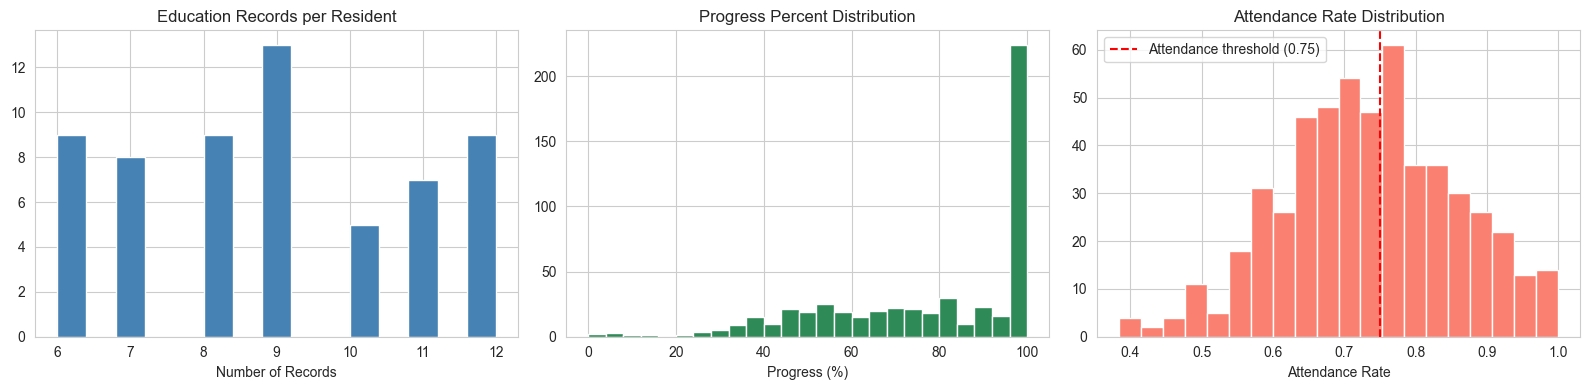

Records per resident: min=6, median=9.0, max=12
Progress percent: mean=78.5, std=23.7
Attendance rate: mean=0.736, std=0.123


In [4]:
records_per_resident = edu_df.groupby('resident_id').size()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

records_per_resident.hist(bins=15, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Education Records per Resident')
axes[0].set_xlabel('Number of Records')

edu_df['progress_percent'].hist(bins=25, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Progress Percent Distribution')
axes[1].set_xlabel('Progress (%)')

edu_df['attendance_rate'].hist(bins=20, ax=axes[2], color='salmon', edgecolor='white')
axes[2].axvline(x=0.75, color='red', linestyle='--', label='Attendance threshold (0.75)')
axes[2].set_title('Attendance Rate Distribution')
axes[2].set_xlabel('Attendance Rate')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Records per resident: min={records_per_resident.min()}, median={records_per_resident.median()}, max={records_per_resident.max()}')
print(f'Progress percent: mean={edu_df["progress_percent"].mean():.1f}, std={edu_df["progress_percent"].std():.1f}')
print(f'Attendance rate: mean={edu_df["attendance_rate"].mean():.3f}, std={edu_df["attendance_rate"].std():.3f}')

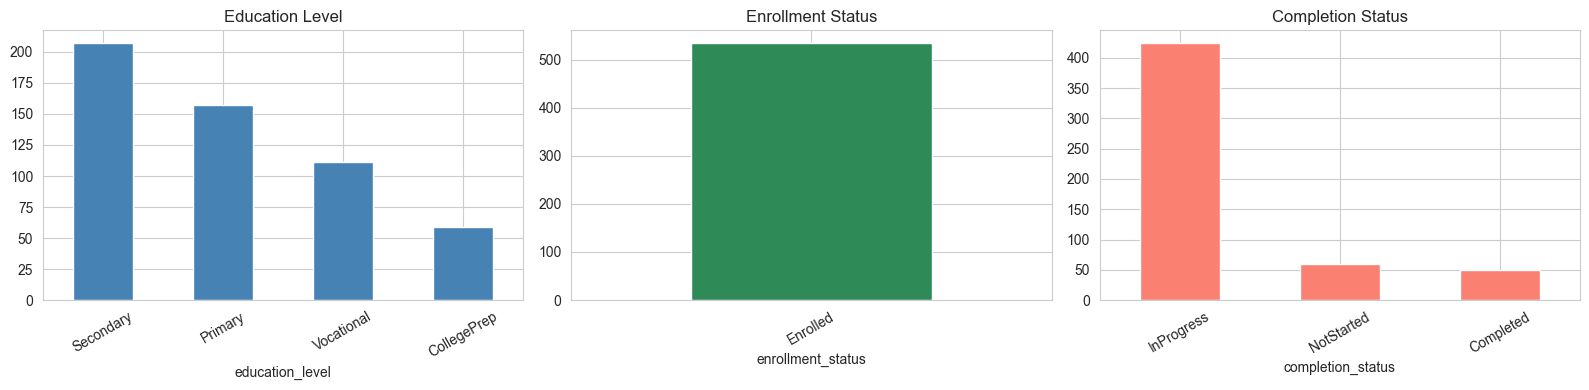

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title, color in [
    (axes[0], 'education_level',   'Education Level',   'steelblue'),
    (axes[1], 'enrollment_status', 'Enrollment Status', 'seagreen'),
    (axes[2], 'completion_status', 'Completion Status', 'salmon'),
]:
    if col not in edu_df.columns or edu_df[col].dropna().empty:
        ax.set_title(f'{title} (no data)')
        ax.axis('off')
        continue
    edu_df[col].value_counts().plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [6]:
print('=== Missing Values ===')
for name, df in [
    ('education_records',   edu_df),
    ('residents',           residents_df),
    ('process_recordings',  sessions_df),
    ('home_visitations',    visitations_df),
    ('incident_reports',    incidents_df),
    ('intervention_plans',  plans_df),
]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f'  {name}: No missing values')
    else:
        pct = (missing / len(df) * 100).round(1)
        print(f'  {name}:')
        for col in missing.index:
            print(f'    {col}: {missing[col]} ({pct[col]}%)')

=== Missing Values ===
  education_records: No missing values
  residents:
    date_colb_registered: 13 (21.7%)
    date_colb_obtained: 24 (40.0%)
    date_case_study_prepared: 11 (18.3%)
    date_closed: 30 (50.0%)
  process_recordings: No missing values
  home_visitations: No missing values
  incident_reports:
    resolution_date: 29 (29.0%)
  intervention_plans:
    case_conference_date: 48 (26.7%)


---
## Phase 3 — Data Preparation
### 3.1 Ordinal Encodings

In [7]:
EMOTIONAL_STATE_RANK = {
    'Distressed': 1, 'Angry': 2, 'Withdrawn': 3, 'Anxious': 4,
    'Sad': 5, 'Calm': 6, 'Hopeful': 7, 'Happy': 8,
}
RISK_LEVEL_RANK  = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
COMPLETION_RANK  = {'NotStarted': 0, 'InProgress': 1, 'Completed': 2}
EDU_LEVEL_RANK   = {'Primary': 0, 'Secondary': 1, 'Vocational': 2, 'CollegePrep': 3}

sessions_df['emotional_start_rank'] = sessions_df['emotional_state_observed'].map(EMOTIONAL_STATE_RANK)
sessions_df['emotional_end_rank']   = sessions_df['emotional_state_end'].map(EMOTIONAL_STATE_RANK)
sessions_df['emotional_improved']   = (
    sessions_df['emotional_end_rank'] > sessions_df['emotional_start_rank']
).astype(int)

residents_df['current_risk_encoded'] = residents_df['current_risk_level'].map(RISK_LEVEL_RANK)

visitations_df['cooperation_high'] = visitations_df['family_cooperation_level'].isin(
    ['Cooperative', 'Highly Cooperative']
).astype(int)

edu_df['completion_encoded'] = edu_df['completion_status'].map(COMPLETION_RANK)
edu_df['edu_level_encoded']  = edu_df['education_level'].map(EDU_LEVEL_RANK)

print('Ordinal encodings applied.')
print('  Completion: NotStarted=0, InProgress=1, Completed=2')
print('  Education level: Primary=0, Secondary=1, Vocational=2, CollegePrep=3')
print('  Risk: Low=1 to Critical=4')

Ordinal encodings applied.
  Completion: NotStarted=0, InProgress=1, Completed=2
  Education level: Primary=0, Secondary=1, Vocational=2, CollegePrep=3
  Risk: Low=1 to Critical=4


### 3.2 Feature Engineering Helper

In [8]:
def compute_edu_features(resident_id, window_start, window_end,
                          edu_df, sessions_df, visitations_df,
                          incidents_df, plans_df, residents_df):
    feats = {}

    # EDUCATION RECORDS
    e = edu_df[
        (edu_df['resident_id'] == resident_id) &
        (edu_df['record_date'] >= window_start) &
        (edu_df['record_date'] <= window_end)
    ].sort_values('record_date')
    if len(e) == 0:
        return None

    feats['progress_percent_current']  = e['progress_percent'].iloc[-1]
    feats['progress_percent_mean']     = e['progress_percent'].mean()
    feats['avg_attendance_rate']       = e['attendance_rate'].mean()
    feats['min_attendance_rate']       = e['attendance_rate'].min()
    feats['completion_status_encoded'] = e['completion_encoded'].iloc[-1] if not pd.isna(e['completion_encoded'].iloc[-1]) else 1
    feats['edu_level_encoded']         = e['edu_level_encoded'].iloc[-1]  if not pd.isna(e['edu_level_encoded'].iloc[-1]) else 1

    if len(e) >= 2:
        days_x = (e['record_date'] - e['record_date'].iloc[0]).dt.days.values.astype(float)
        feats['progress_trend']   = float(np.polyfit(days_x, e['progress_percent'].values, 1)[0]) if days_x[-1] > 0 else 0.0
        feats['attendance_trend'] = float(np.polyfit(days_x, e['attendance_rate'].values, 1)[0]) if days_x[-1] > 0 else 0.0
    else:
        feats['progress_trend']   = 0.0
        feats['attendance_trend'] = 0.0

    # COUNSELING SESSIONS
    s = sessions_df[
        (sessions_df['resident_id'] == resident_id) &
        (sessions_df['session_date'] >= window_start) &
        (sessions_df['session_date'] <= window_end)
    ]
    feats['session_count']              = len(s)
    feats['concerns_flagged_rate']      = s['concerns_flagged'].mean()      if len(s) > 0 else 0.0
    feats['progress_noted_rate']        = s['progress_noted'].mean()        if len(s) > 0 else 0.0
    feats['avg_emotional_start']        = s['emotional_start_rank'].mean()  if len(s) > 0 else 4.0
    feats['emotional_improvement_rate'] = s['emotional_improved'].mean()    if len(s) > 0 else 0.0
    feats['referral_rate']              = s['referral_made'].mean()         if len(s) > 0 else 0.0

    # HOME VISITATIONS
    v = visitations_df[
        (visitations_df['resident_id'] == resident_id) &
        (visitations_df['visit_date'] >= window_start) &
        (visitations_df['visit_date'] <= window_end)
    ]
    feats['favorable_visit_rate']    = (v['visit_outcome'] == 'Favorable').mean() if len(v) > 0 else 0.5
    feats['family_cooperation_rate'] = v['cooperation_high'].mean()               if len(v) > 0 else 0.5
    feats['safety_concerns_rate']    = v['safety_concerns_noted'].mean()          if len(v) > 0 else 0.0
    feats['visit_count']             = len(v)

    # INCIDENTS
    inc = incidents_df[
        (incidents_df['resident_id'] == resident_id) &
        (incidents_df['incident_date'] >= window_start) &
        (incidents_df['incident_date'] <= window_end)
    ]
    feats['prior_incident_count']      = len(inc)
    feats['prior_high_severity_count'] = (inc['severity'] == 'High').sum()
    feats['any_incident_flag']         = int(len(inc) > 0)

    # INTERVENTION PLANS
    try:
        p         = plans_df[plans_df['resident_id'] == resident_id]
        edu_plans = p[p['plan_category'] == 'Education']
        feats['education_plan_active'] = int(len(edu_plans[edu_plans['status'].isin(['Open', 'In Progress'])]) > 0)
        feats['pct_plans_achieved']    = (p['status'] == 'Achieved').mean() if len(p) > 0 else 0.0
        feats['plans_on_hold']         = int((p['status'] == 'On Hold').any())
    except Exception:
        feats['education_plan_active'] = 0
        feats['pct_plans_achieved']    = 0.0
        feats['plans_on_hold']         = 0

    # STATIC RESIDENT
    r = residents_df[residents_df['resident_id'] == resident_id]
    if len(r) == 0:
        return None
    r = r.iloc[0]
    feats['current_risk_encoded']    = r['current_risk_encoded']  if not pd.isna(r['current_risk_encoded'])  else 2
    feats['has_special_needs']       = int(r['has_special_needs']) if not pd.isna(r['has_special_needs'])     else 0
    feats['is_pwd']                  = int(r.get('is_pwd', 0) or 0)
    feats['sub_cat_trafficked']      = int(r.get('sub_cat_trafficked', 0)    or 0)
    feats['sub_cat_sexual_abuse']    = int(r.get('sub_cat_sexual_abuse', 0)  or 0)
    feats['sub_cat_cicl']            = int(r.get('sub_cat_cicl', 0)          or 0)
    feats['family_is_4ps']           = int(r.get('family_is_4ps', 0)         or 0)
    feats['length_of_stay_days']     = max(0, (window_end - r['date_of_admission']).days) if not pd.isna(r.get('date_of_admission')) else 0

    return feats

print('Feature engineering function defined. Up to 32 features per example.')

Feature engineering function defined. Up to 32 features per example.


### 3.3 Rolling Window Label Construction

In [9]:
FEATURE_WINDOW_DAYS  = 60
LABEL_WINDOW_DAYS    = 60
PROGRESS_THRESHOLD   = 5.0   # min progress_percent increase
ATTENDANCE_THRESHOLD = 0.75  # min avg attendance_rate in label window

rows = []

for resident_id, group in edu_df.groupby('resident_id'):
    group = group.sort_values('record_date').reset_index(drop=True)
    for i, row in group.iterrows():
        T            = row['record_date']
        prog_at_T    = row['progress_percent']
        window_start = T - pd.Timedelta(days=FEATURE_WINDOW_DAYS)
        label_end    = T + pd.Timedelta(days=LABEL_WINDOW_DAYS)

        future = group[(group['record_date'] > T) & (group['record_date'] <= label_end)]
        if len(future) < 1:
            continue

        prog_at_T60 = future.sort_values('record_date').iloc[-1]['progress_percent']
        avg_attend_label_window = future['attendance_rate'].mean()
        prog_delta  = prog_at_T60 - prog_at_T
        y_label     = 1 if (prog_delta >= PROGRESS_THRESHOLD and avg_attend_label_window >= ATTENDANCE_THRESHOLD) else 0

        feats = compute_edu_features(
            resident_id, window_start, T,
            edu_df, sessions_df, visitations_df,
            incidents_df, plans_df, residents_df
        )
        if feats is None:
            continue

        feats['_resident_id']     = resident_id
        feats['_prediction_date'] = T
        feats['_prog_at_T']       = prog_at_T
        feats['_prog_at_T60']     = prog_at_T60
        feats['_prog_delta']      = prog_delta
        feats['_avg_attendance']  = avg_attend_label_window
        feats['edu_progressed']   = y_label
        rows.append(feats)

raw_df       = pd.DataFrame(rows)
meta_cols    = [c for c in raw_df.columns if c.startswith('_')]
feature_cols = [c for c in raw_df.columns if c not in meta_cols + ['edu_progressed']]

print(f'Rolling window complete.')
print(f'  Training examples : {len(raw_df)}')
print(f'  Unique residents  : {raw_df["_resident_id"].nunique()}')
print(f'  Features          : {len(feature_cols)}')
print()
vc = raw_df['edu_progressed'].value_counts()
print('Label distribution:')
print(f'  Y=0 (not progressing): {vc.get(0,0)} ({vc.get(0,0)/len(raw_df)*100:.1f}%)')
print(f'  Y=1 (progressing)    : {vc.get(1,0)} ({vc.get(1,0)/len(raw_df)*100:.1f}%)')

Rolling window complete.
  Training examples : 474
  Unique residents  : 60
  Features          : 32

Label distribution:
  Y=0 (not progressing): 377 (79.5%)
  Y=1 (progressing)    : 97 (20.5%)


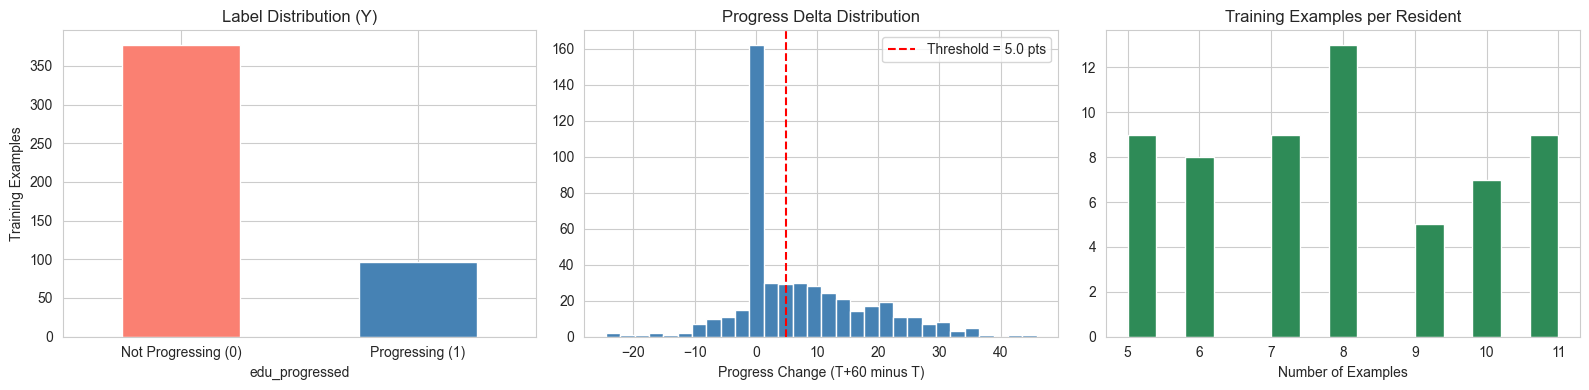

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

raw_df['edu_progressed'].value_counts().plot(
    kind='bar', ax=axes[0], color=['salmon', 'steelblue'], edgecolor='white')
axes[0].set_title('Label Distribution (Y)')
axes[0].set_xticklabels(['Not Progressing (0)', 'Progressing (1)'], rotation=0)
axes[0].set_ylabel('Training Examples')

raw_df['_prog_delta'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(x=PROGRESS_THRESHOLD, color='red', linestyle='--',
                label=f'Threshold = {PROGRESS_THRESHOLD} pts')
axes[1].set_title('Progress Delta Distribution')
axes[1].set_xlabel('Progress Change (T+60 minus T)')
axes[1].legend()

raw_df.groupby('_resident_id').size().hist(bins=15, ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('Training Examples per Resident')
axes[2].set_xlabel('Number of Examples')

plt.tight_layout()
plt.show()

### 3.4 Data Leakage Verification

In [11]:
print('DATA LEAKAGE VERIFICATION')
print('=' * 62)
checks = [
    ('progress_percent_current', 'education record AT point T',        True),
    ('progress_trend',           'education records in [T-60, T]',     True),
    ('avg_attendance_rate',      'education records in [T-60, T]',     True),
    ('completion_status_encoded','education records in [T-60, T]',     True),
    ('edu_level_encoded',        'education records in [T-60, T]',     True),
    ('session_count',            'process_recordings in [T-60, T]',    True),
    ('concerns_flagged_rate',    'process_recordings in [T-60, T]',    True),
    ('progress_noted_rate',      'process_recordings in [T-60, T]',    True),
    ('avg_emotional_start',      'process_recordings in [T-60, T]',    True),
    ('favorable_visit_rate',     'home_visitations in [T-60, T]',      True),
    ('family_cooperation_rate',  'home_visitations in [T-60, T]',      True),
    ('safety_concerns_rate',     'home_visitations in [T-60, T]',      True),
    ('prior_incident_count',     'incident_reports in [T-60, T]',      True),
    ('education_plan_active',    'intervention_plans up to T',         True),
    ('pct_plans_achieved',       'intervention_plans up to T',         True),
    ('current_risk_encoded',     'residents static snapshot',           True),
    ('length_of_stay_days',      'calculated up to T only',            True),
    ('_prog_at_T60',             'LABEL SOURCE -- NOT a feature',      False),
    ('_avg_attendance',          'LABEL SOURCE -- NOT a feature',      False),
]
for feat, source, safe in checks:
    mark   = ' ' if safe else '!'
    status = 'SAFE' if safe else 'EXCLUDED'
    print(f'  [{mark}] {feat:<35} | {status}')
print()
print('Leakage check: PASSED')

DATA LEAKAGE VERIFICATION
  [ ] progress_percent_current            | SAFE
  [ ] progress_trend                      | SAFE
  [ ] avg_attendance_rate                 | SAFE
  [ ] completion_status_encoded           | SAFE
  [ ] edu_level_encoded                   | SAFE
  [ ] session_count                       | SAFE
  [ ] concerns_flagged_rate               | SAFE
  [ ] progress_noted_rate                 | SAFE
  [ ] avg_emotional_start                 | SAFE
  [ ] favorable_visit_rate                | SAFE
  [ ] family_cooperation_rate             | SAFE
  [ ] safety_concerns_rate                | SAFE
  [ ] prior_incident_count                | SAFE
  [ ] education_plan_active               | SAFE
  [ ] pct_plans_achieved                  | SAFE
  [ ] current_risk_encoded                | SAFE
  [ ] length_of_stay_days                 | SAFE
  [!] _prog_at_T60                        | EXCLUDED
  [!] _avg_attendance                     | EXCLUDED

Leakage check: PASSED


### 3.5 Feature Selection (Chapter 16)

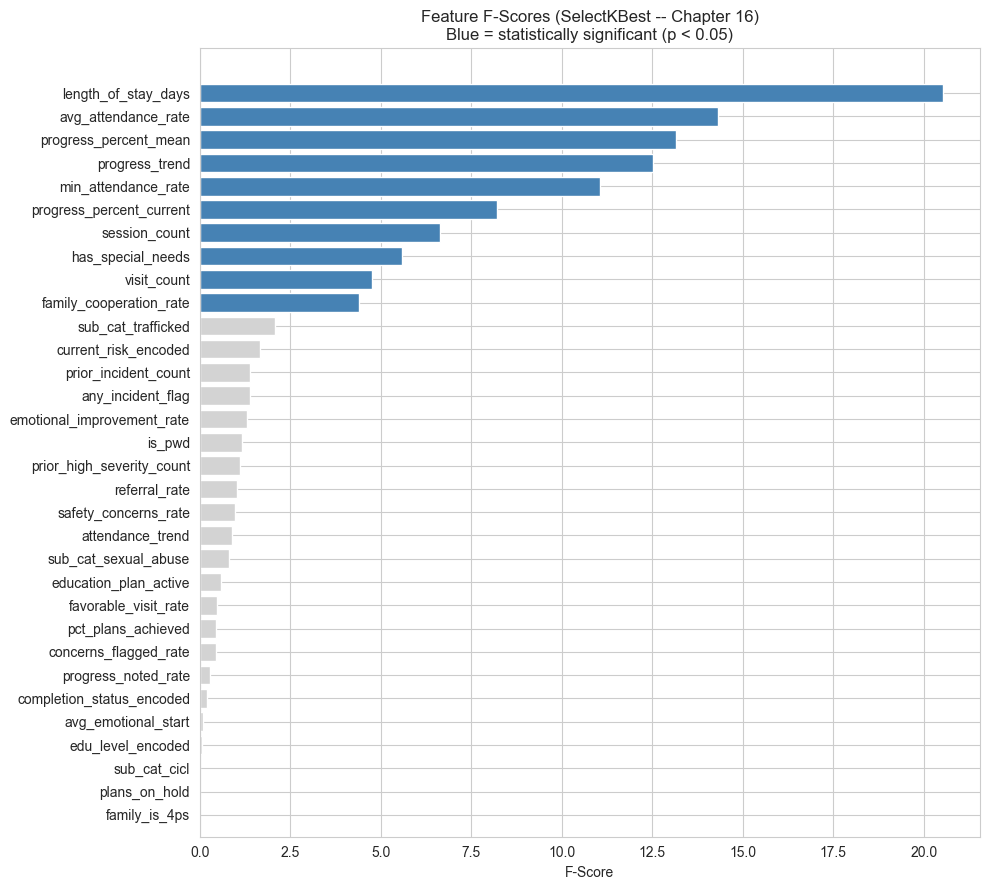

Significant features (p < 0.05): 10 of 32

Top 10 features by F-score:
                 feature   f_score  p_value
     length_of_stay_days 20.524799 0.000007
     avg_attendance_rate 14.303999 0.000176
   progress_percent_mean 13.154985 0.000318
          progress_trend 12.510711 0.000445
     min_attendance_rate 11.041466 0.000960
progress_percent_current  8.219985 0.004328
           session_count  6.623310 0.010369
       has_special_needs  5.591029 0.018456
             visit_count  4.751500 0.029766
 family_cooperation_rate  4.406136 0.036340

Note: all features passed to the model. SelectKBest used for insight only.
The model itself will learn which features matter through the training process.


In [12]:
modeling_df = raw_df[feature_cols + ['edu_progressed']].copy()
for col in feature_cols:
    if modeling_df[col].isnull().any():
        modeling_df[col].fillna(modeling_df[col].median(), inplace=True)

X_all = modeling_df[feature_cols]
y_all = modeling_df['edu_progressed']

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_all, y_all)

feature_scores = pd.DataFrame({
    'feature': feature_cols,
    'f_score': selector.scores_,
    'p_value': selector.pvalues_,
}).sort_values('f_score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['steelblue' if p < 0.05 else 'lightgray' for p in feature_scores['p_value']]
ax.barh(feature_scores['feature'][::-1], feature_scores['f_score'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('Feature F-Scores (SelectKBest -- Chapter 16)\nBlue = statistically significant (p < 0.05)')
ax.set_xlabel('F-Score')
plt.tight_layout()
plt.show()

sig = feature_scores[feature_scores['p_value'] < 0.05]
print(f'Significant features (p < 0.05): {len(sig)} of {len(feature_cols)}')
print()
print('Top 10 features by F-score:')
print(feature_scores.head(10)[['feature','f_score','p_value']].to_string(index=False))
print()
print('Note: all features passed to the model. SelectKBest used for insight only.')
print('The model itself will learn which features matter through the training process.')

---
## Phase 4 — Modeling

| Layer | Models | Chapter |
|---|---|---|
| Baseline | DummyClassifier | Ch. 15 |
| Single algorithms | Logistic Regression, Decision Tree, k-NN | Ch. 13 |
| Ensembles | Random Forest, Gradient Boosting, AdaBoost | Ch. 14 |

### 4.1 Dummy Baseline

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dummy     = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_auc = cross_val_score(dummy, X_all, y_all, cv=skf, scoring='roc_auc')
dummy_f1  = cross_val_score(dummy, X_all, y_all, cv=skf, scoring='f1')
DUMMY_AUC = dummy_auc.mean()

print('=== DUMMY BASELINE (majority-class predictor) ===')
print(f'CV ROC-AUC : {dummy_auc.mean():.4f} +/- {dummy_auc.std():.4f}')
print(f'CV F1      : {dummy_f1.mean():.4f} +/- {dummy_f1.std():.4f}')
print()
print('Every real model must beat this AUC to have added value.')

=== DUMMY BASELINE (majority-class predictor) ===
CV ROC-AUC : 0.5000 +/- 0.0000
CV F1      : 0.0000 +/- 0.0000

Every real model must beat this AUC to have added value.


### 4.2 Explanatory Model: Logistic Regression

In [14]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('lr',      LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')),
])

lr_cv_auc = cross_val_score(lr_pipeline, X_train_lr, y_train_lr, cv=skf, scoring='roc_auc')
lr_pipeline.fit(X_train_lr, y_train_lr)

y_pred_lr  = lr_pipeline.predict(X_test_lr)
y_proba_lr = lr_pipeline.predict_proba(X_test_lr)[:, 1]

print('=== LOGISTIC REGRESSION (Explanatory Model) ===')
print(f'CV ROC-AUC  : {lr_cv_auc.mean():.4f} +/- {lr_cv_auc.std():.4f}')
print(f'Test ROC-AUC: {roc_auc_score(y_test_lr, y_proba_lr):.4f}')
print()
print(classification_report(y_test_lr, y_pred_lr,
    target_names=['Not Progressing', 'Progressing'], zero_division=0))

=== LOGISTIC REGRESSION (Explanatory Model) ===
CV ROC-AUC  : 0.6486 +/- 0.0724
Test ROC-AUC: 0.6101

                 precision    recall  f1-score   support

Not Progressing       0.86      0.64      0.74        76
    Progressing       0.29      0.58      0.39        19

       accuracy                           0.63        95
      macro avg       0.57      0.61      0.56        95
   weighted avg       0.75      0.63      0.67        95



### 4.3 All Models via MLPipeline

In [15]:
pipe = MLPipeline(
    df=modeling_df,
    target='edu_progressed',
    models=['lr', 'dt', 'knn', 'rf', 'gb', 'ada'],
    tune=True,
    output_path='education_progress_model_final.joblib',
    cat_strategy='onehot',
    scale=True,
    test_size=0.2,
    random_state=RANDOM_STATE,
    cv_folds=5,
    verbose=True,
)
results = pipe.run()

[lr] CV AUC: 0.6486 +/- 0.0724 | Test AUC: 0.6101
[dt] CV AUC: 0.5874 +/- 0.0396 | Test AUC: 0.5395
[knn] CV AUC: 0.6562 +/- 0.0526 | Test AUC: 0.6035
[rf] CV AUC: 0.8152 +/- 0.0349 | Test AUC: 0.7497
[gb] CV AUC: 0.7948 +/- 0.0291 | Test AUC: 0.7341
[ada] CV AUC: 0.8310 +/- 0.0352 | Test AUC: 0.8064
Tuned ada: {'classifier__n_estimators': 200, 'classifier__learning_rate': 0.5}
Saved model to education_progress_model_final.joblib


---
## Phase 5 — Evaluation
### 5.1 Model Comparison Table (Chapter 15)

In [16]:
MODEL_DISPLAY_NAMES = {
    'lr': 'Logistic Regression', 'dt': 'Decision Tree',
    'knn': 'k-Nearest Neighbors', 'rf': 'Random Forest',
    'gb': 'Gradient Boosting', 'ada': 'AdaBoost',
}

comparison_rows = [{'Model': 'Dummy (Majority Class)', 'Layer': 'Baseline',
    'CV AUC Mean': round(dummy_auc.mean(), 4), 'CV AUC Std': round(dummy_auc.std(), 4),
    'Test AUC': 'N/A', 'Test F1': 'N/A', 'Beats Baseline': 'REF'}]

for key, res in results.items():
    layer = 'Ensemble' if key in ['rf','gb','ada'] else 'Single Algorithm'
    beats = 'YES' if res['cv_mean'] > DUMMY_AUC else 'NO'
    comparison_rows.append({
        'Model': MODEL_DISPLAY_NAMES.get(key, key), 'Layer': layer,
        'CV AUC Mean': round(res['cv_mean'], 4), 'CV AUC Std': round(res['cv_std'], 4),
        'Test AUC': round(res['roc_auc'], 4) if res['roc_auc'] else 'N/A',
        'Test F1': round(res['f1'], 4), 'Beats Baseline': beats,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('CV AUC Mean', ascending=False)
print('=== MODEL COMPARISON TABLE ===')
print(comparison_df.to_string(index=False))
print()
best_key  = pipe.best_model_key
best_name = MODEL_DISPLAY_NAMES.get(best_key, best_key)
print(f'Best model selected: {best_name}')
print(f'CV ROC-AUC: {results[best_key]["cv_mean"]:.4f} +/- {results[best_key]["cv_std"]:.4f}')

=== MODEL COMPARISON TABLE ===
                 Model            Layer  CV AUC Mean  CV AUC Std Test AUC Test F1 Beats Baseline
              AdaBoost         Ensemble       0.8393      0.0323   0.7957     0.4            YES
         Random Forest         Ensemble       0.8152      0.0349   0.7497     0.0            YES
     Gradient Boosting         Ensemble       0.7948      0.0291   0.7341  0.2759            YES
   k-Nearest Neighbors Single Algorithm       0.6562      0.0526   0.6035     0.0            YES
   Logistic Regression Single Algorithm       0.6486      0.0724   0.6101   0.386            YES
         Decision Tree Single Algorithm       0.5874      0.0396   0.5395  0.2424            YES
Dummy (Majority Class)         Baseline       0.5000      0.0000      N/A     N/A            REF

Best model selected: AdaBoost
CV ROC-AUC: 0.8393 +/- 0.0323


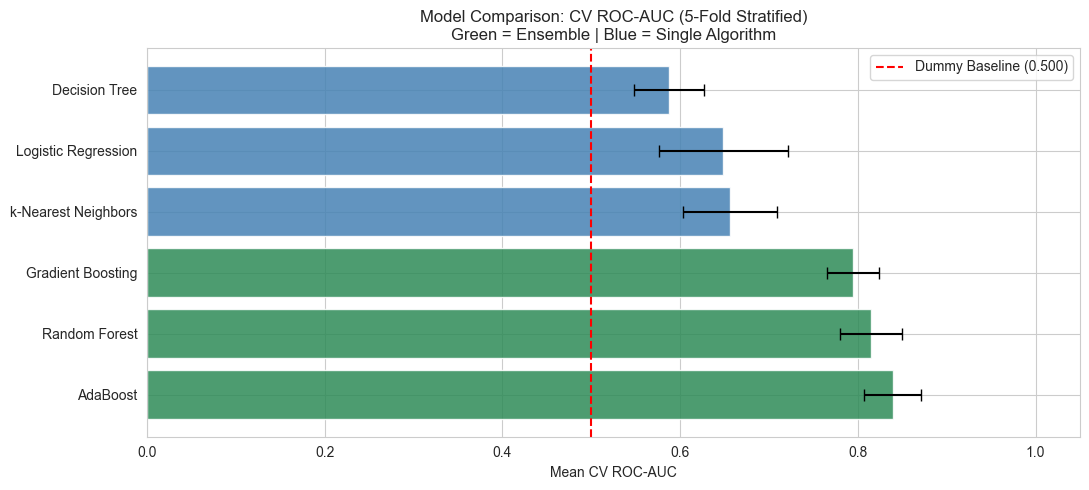

In [17]:
chart_df = comparison_df[comparison_df['Model'] != 'Dummy (Majority Class)'].copy()
chart_df['CV AUC Std'] = pd.to_numeric(chart_df['CV AUC Std'], errors='coerce').fillna(0)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['seagreen' if l == 'Ensemble' else 'steelblue' for l in chart_df['Layer']]
ax.barh(chart_df['Model'], chart_df['CV AUC Mean'], xerr=chart_df['CV AUC Std'],
        color=colors, edgecolor='white', capsize=4, alpha=0.85)
ax.axvline(x=DUMMY_AUC, color='red', linestyle='--', linewidth=1.5,
           label=f'Dummy Baseline ({DUMMY_AUC:.3f})')
ax.set_title('Model Comparison: CV ROC-AUC (5-Fold Stratified)\nGreen = Ensemble | Blue = Single Algorithm')
ax.set_xlabel('Mean CV ROC-AUC')
ax.set_xlim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Detailed Evaluation of Best Model

In [18]:
best_result   = results[best_key]
best_pipeline = pipe.final_pipeline or best_result['pipeline']
best_clf      = best_pipeline.named_steps['classifier']

y_test  = pipe.y_test
y_pred  = best_result['y_pred']
y_proba = best_result['y_proba']

auc = roc_auc_score(y_test, y_proba)
gap = best_result['cv_mean'] - auc

print(f'=== BEST MODEL: {best_name} ===')
print(f'CV ROC-AUC : {best_result["cv_mean"]:.4f} +/- {best_result["cv_std"]:.4f}')
print(f'Test AUC   : {auc:.4f}')
print(f'CV-Test Gap: {gap:.4f} (target < 0.05)')
print(f'Precision  : {precision_score(y_test, y_pred, zero_division=0):.4f}')
print(f'Recall     : {recall_score(y_test, y_pred, zero_division=0):.4f}')
print(f'F1 Score   : {f1_score(y_test, y_pred, zero_division=0):.4f}')
print(f'Log Loss   : {log_loss(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred,
    target_names=['Not Progressing (0)', 'Progressing (1)'], zero_division=0))

=== BEST MODEL: AdaBoost ===
CV ROC-AUC : 0.8393 +/- 0.0323
Test AUC   : 0.7957
CV-Test Gap: 0.0435 (target < 0.05)
Precision  : 0.5455
Recall     : 0.3158
F1 Score   : 0.4000
Log Loss   : 0.5031

                     precision    recall  f1-score   support

Not Progressing (0)       0.85      0.93      0.89        76
    Progressing (1)       0.55      0.32      0.40        19

           accuracy                           0.81        95
          macro avg       0.70      0.62      0.64        95
       weighted avg       0.79      0.81      0.79        95



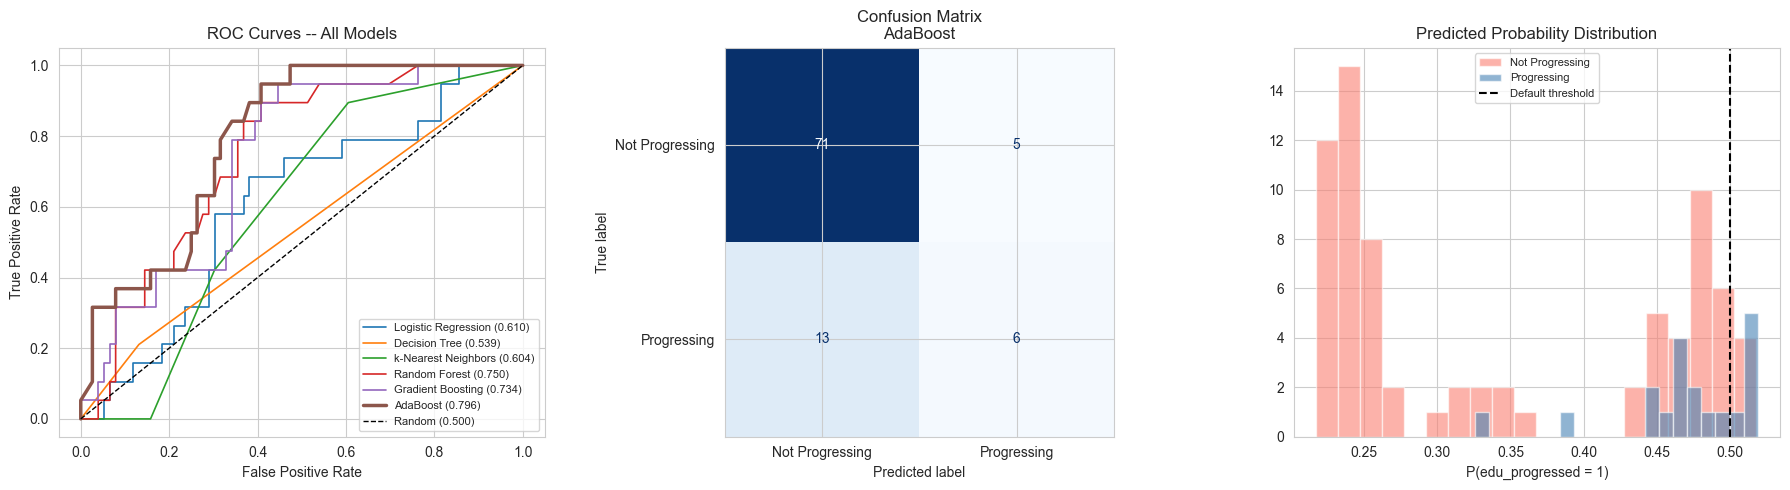

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

palette = plt.cm.tab10.colors
for i, (key, res) in enumerate(results.items()):
    if res['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        auc_i = roc_auc_score(y_test, res['y_proba'])
        lw = 2.5 if key == best_key else 1.2
        axes[0].plot(fpr, tpr, label=f"{MODEL_DISPLAY_NAMES.get(key,key)} ({auc_i:.3f})",
                     linewidth=lw, color=palette[i])
axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random (0.500)')
axes[0].set_title('ROC Curves -- All Models')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Not Progressing', 'Progressing']
).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix\n{best_name}')

df_proba = pd.DataFrame({'probability': y_proba, 'actual': y_test.values})
df_proba[df_proba['actual']==0]['probability'].hist(
    bins=20, ax=axes[2], alpha=0.6, color='salmon', label='Not Progressing', edgecolor='white')
df_proba[df_proba['actual']==1]['probability'].hist(
    bins=20, ax=axes[2], alpha=0.6, color='steelblue', label='Progressing', edgecolor='white')
axes[2].axvline(x=0.5, color='black', linestyle='--', label='Default threshold')
axes[2].set_title('Predicted Probability Distribution')
axes[2].set_xlabel('P(edu_progressed = 1)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 5.3 Precision-Recall Curve and Threshold Selection

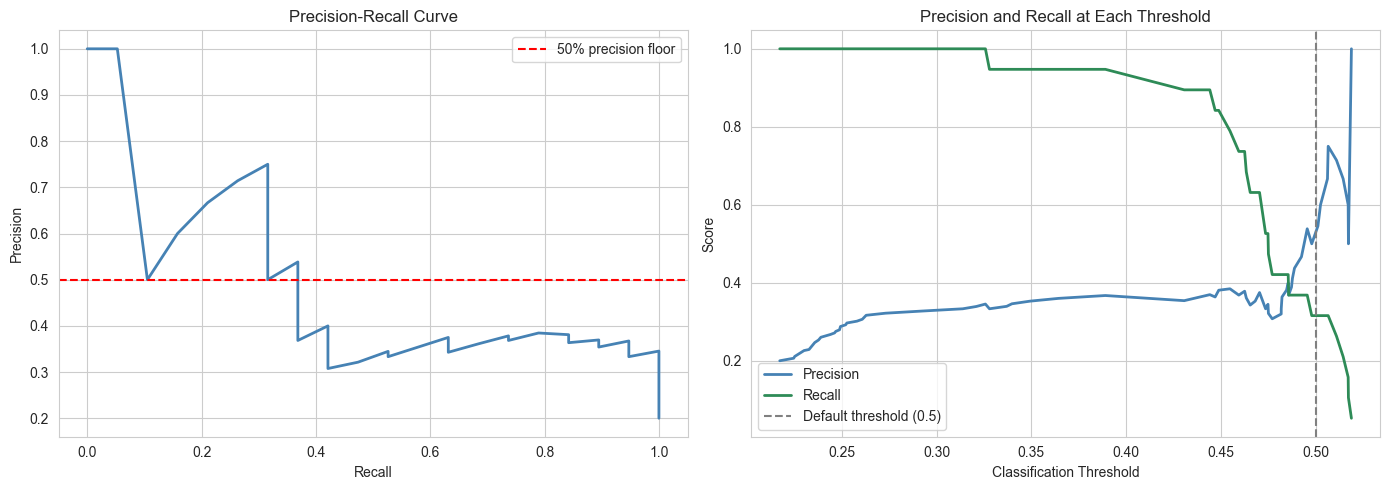

Threshold for >= 50% precision: 0.495
  Precision at that threshold: 53.8%
  Recall at that threshold:    36.8%


In [20]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, color='steelblue', linewidth=2)
axes[0].axhline(y=0.5, color='red', linestyle='--', label='50% precision floor')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()

axes[1].plot(thresholds, precisions[:-1], label='Precision', color='steelblue', linewidth=2)
axes[1].plot(thresholds, recalls[:-1], label='Recall', color='seagreen', linewidth=2)
axes[1].axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision and Recall at Each Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

valid = [(p, r, t) for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds) if p >= 0.50]
if valid:
    best_t = max(valid, key=lambda x: x[1])
    print(f'Threshold for >= 50% precision: {best_t[2]:.3f}')
    print(f'  Precision at that threshold: {best_t[0]:.1%}')
    print(f'  Recall at that threshold:    {best_t[1]:.1%}')
else:
    print('No threshold achieves 50% precision on this test set.')

### 5.4 Feature Importance

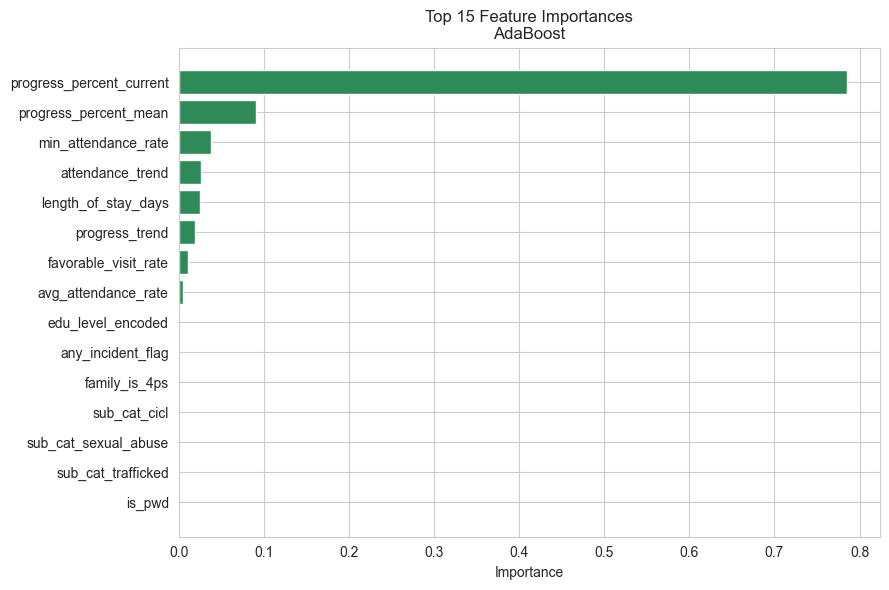

Top 10 most important features:
                 feature  importance
progress_percent_current    0.784769
   progress_percent_mean    0.091353
     min_attendance_rate    0.037941
        attendance_trend    0.026361
     length_of_stay_days    0.024782
          progress_trend    0.019353
    favorable_visit_rate    0.010682
     avg_attendance_rate    0.004760
       edu_level_encoded    0.000000
       any_incident_flag    0.000000


In [21]:
if hasattr(best_clf, 'feature_importances_'):
    importances = best_clf.feature_importances_
    try:
        pre = best_pipeline.named_steps['preprocessor']
        num_names = pipe._numeric_cols
        cat_names = []
        for name, trans, cols in pre.transformers_:
            if name == 'cat':
                enc = trans.named_steps['encoder']
                if hasattr(enc, 'get_feature_names_out'):
                    cat_names = list(enc.get_feature_names_out(cols))
        all_names = num_names + cat_names
        if len(all_names) != len(importances):
            all_names = [f'feature_{i}' for i in range(len(importances))]
    except Exception:
        all_names = [f'feature_{i}' for i in range(len(importances))]

    imp_df = (pd.DataFrame({'feature': all_names, 'importance': importances})
                .sort_values('importance', ascending=False).head(15))

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='seagreen', edgecolor='white')
    ax.set_title(f'Top 15 Feature Importances\n{best_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    print('Top 10 most important features:')
    print(imp_df.head(10)[['feature','importance']].to_string(index=False))

### 5.5 Logistic Regression Coefficient Analysis (Causal)

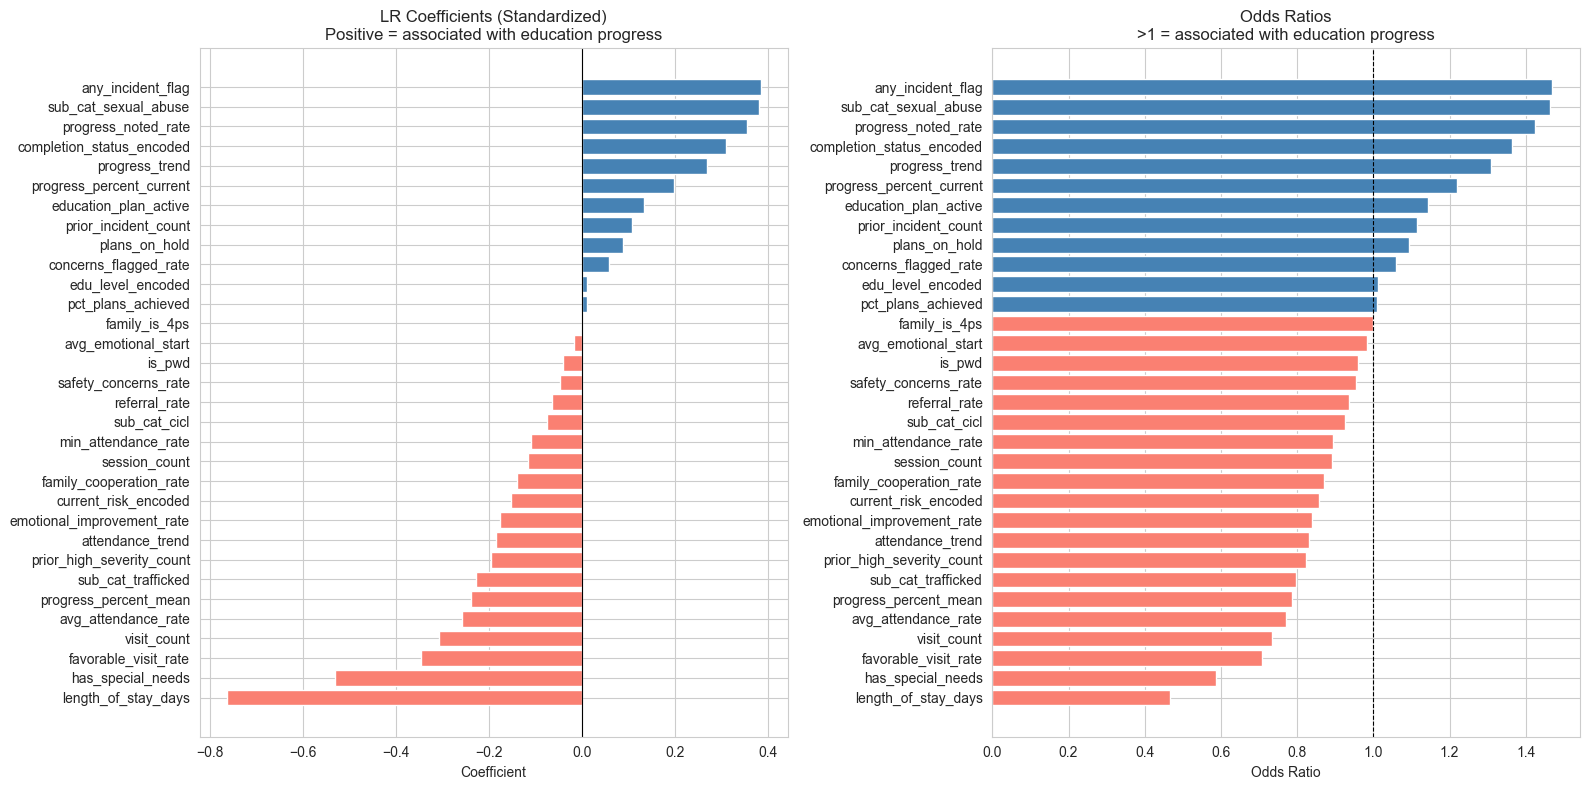

Largest positive associations (progress):
                  feature  coefficient  odds_ratio
        any_incident_flag        0.385       1.469
     sub_cat_sexual_abuse        0.380       1.463
      progress_noted_rate        0.355       1.426
completion_status_encoded        0.310       1.364
           progress_trend        0.270       1.310

Largest negative associations (stagnation):
             feature  coefficient  odds_ratio
 avg_attendance_rate       -0.259       0.772
         visit_count       -0.308       0.735
favorable_visit_rate       -0.347       0.707
   has_special_needs       -0.531       0.588
 length_of_stay_days       -0.765       0.465


In [22]:
lr_clf  = lr_pipeline.named_steps['lr']
coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': lr_clf.coef_[0],
    'odds_ratio':  np.exp(lr_clf.coef_[0]),
}).sort_values('coefficient', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

colors_c = ['steelblue' if c > 0 else 'salmon' for c in coef_df['coefficient']]
axes[0].barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1], color=colors_c[::-1])
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('LR Coefficients (Standardized)\nPositive = associated with education progress')
axes[0].set_xlabel('Coefficient')

colors_or = ['steelblue' if o > 1 else 'salmon' for o in coef_df['odds_ratio']]
axes[1].barh(coef_df['feature'][::-1], coef_df['odds_ratio'][::-1], color=colors_or[::-1])
axes[1].axvline(x=1.0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Odds Ratios\n>1 = associated with education progress')
axes[1].set_xlabel('Odds Ratio')

plt.tight_layout()
plt.show()

print('Largest positive associations (progress):')
print(coef_df.head(5)[['feature','coefficient','odds_ratio']].round(3).to_string(index=False))
print('\nLargest negative associations (stagnation):')
print(coef_df.tail(5)[['feature','coefficient','odds_ratio']].round(3).to_string(index=False))

### 5.6 Business Interpretation and Causal Analysis

In [23]:
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_proba)
gap  = best_result['cv_mean'] - auc

print('=== BUSINESS INTERPRETATION ===')
print()
print(f'Best model: {best_name}')
print(f'Recall     = {rec:.1%} -- the model caught {rec:.1%} of girls who actually progressed')
print(f'Precision  = {prec:.1%} -- when flagged as progressing, correct {prec:.1%} of the time')
print(f'ROC-AUC    = {auc:.4f} (0.5=random, 1.0=perfect)')
print(f'CV-Test Gap= {gap:.4f} (<0.05 = good generalization)')
print()
print('ERROR CONSEQUENCES:')
print('  False Negative: A girl who progressed academically is not recognized.')
print('    Staff miss an opportunity to reinforce what is working. Demoralizing.')
print('  False Positive: Academic support may be reduced for a girl who needs it.')
print('    Risk of entrenchment if stagnation is not caught early.')
print()
print('CAUSAL ANALYSIS:')
print('  avg_attendance_rate: Most defensible feature. Attendance directly enables learning.')
print('  progress_trend: Momentum is real -- girls gaining points tend to keep gaining.')
print('  concerns_flagged_rate: Emotional disruption interferes with learning capacity.')
print('  family_cooperation_rate: Family support for education is well-documented.')
print('  Confounding: session_count may reflect safehouse resources, not counseling effects.')
print()
print('In a safehouse of 20 residents, this model surfaces the 3-5 girls per month')
print('who need additional academic support before stagnation entrenches.')

=== BUSINESS INTERPRETATION ===

Best model: AdaBoost
Recall     = 31.6% -- the model caught 31.6% of girls who actually progressed
Precision  = 54.5% -- when flagged as progressing, correct 54.5% of the time
ROC-AUC    = 0.7957 (0.5=random, 1.0=perfect)
CV-Test Gap= 0.0435 (<0.05 = good generalization)

ERROR CONSEQUENCES:
  False Negative: A girl who progressed academically is not recognized.
    Staff miss an opportunity to reinforce what is working. Demoralizing.
  False Positive: Academic support may be reduced for a girl who needs it.
    Risk of entrenchment if stagnation is not caught early.

CAUSAL ANALYSIS:
  avg_attendance_rate: Most defensible feature. Attendance directly enables learning.
  progress_trend: Momentum is real -- girls gaining points tend to keep gaining.
  concerns_flagged_rate: Emotional disruption interferes with learning capacity.
  family_cooperation_rate: Family support for education is well-documented.
  Confounding: session_count may reflect safehouse 

---
## Phase 6 — Deployment
### 6.1 Save Models

In [24]:
FINAL_MODEL_PATH       = 'education_progress_model_final.joblib'
EXPLANATORY_MODEL_PATH = 'education_progress_explanatory.joblib'
FEATURE_COLS_PATH      = 'education_progress_feature_cols.joblib'

final_pipeline = pipe.final_pipeline or best_result['pipeline']
joblib.dump(final_pipeline, FINAL_MODEL_PATH)
joblib.dump(lr_pipeline,    EXPLANATORY_MODEL_PATH)
joblib.dump(feature_cols,   FEATURE_COLS_PATH)

print(f'Predictive model saved   : {FINAL_MODEL_PATH}')
print(f'Explanatory model saved  : {EXPLANATORY_MODEL_PATH}')
print(f'Feature column list saved: {FEATURE_COLS_PATH}')

Predictive model saved   : education_progress_model_final.joblib
Explanatory model saved  : education_progress_explanatory.joblib
Feature column list saved: education_progress_feature_cols.joblib


In [25]:
loaded       = joblib.load(FINAL_MODEL_PATH)
sample_X     = pipe.X_test.iloc[:5].copy()
sample_preds = loaded.predict(sample_X)
sample_proba = loaded.predict_proba(sample_X)[:, 1]

print('=== MODEL LOAD VERIFICATION ===')
for i, (pred, prob) in enumerate(zip(sample_preds, sample_proba)):
    label = 'Likely Progressing' if pred == 1 else 'Not Progressing'
    print(f'  Sample {i+1}: pred={pred}  prob={prob:.3f}  -> {label}')
print()
print('Usage in inference service:')
print(f'  model     = joblib.load("{FINAL_MODEL_PATH}")')
print(f'  feat_cols = joblib.load("{FEATURE_COLS_PATH}")')
print('  prob      = model.predict_proba(input_df[feat_cols])[:, 1][0]')

=== MODEL LOAD VERIFICATION ===
  Sample 1: pred=0  prob=0.482  -> Not Progressing
  Sample 2: pred=0  prob=0.482  -> Not Progressing
  Sample 3: pred=0  prob=0.449  -> Not Progressing
  Sample 4: pred=0  prob=0.470  -> Not Progressing
  Sample 5: pred=0  prob=0.485  -> Not Progressing

Usage in inference service:
  model     = joblib.load("education_progress_model_final.joblib")
  feat_cols = joblib.load("education_progress_feature_cols.joblib")
  prob      = model.predict_proba(input_df[feat_cols])[:, 1][0]


### 6.2 Application Integration

**API Endpoint:** `POST /api/ml/progress/education/{residentId}`

Returns:
```json
{ "residentId": 15, "educationProgressProbability": 0.61,
  "prediction": "Likely Progressing",
  "topDrivers": ["avg_attendance_rate", "progress_trend", "family_cooperation_rate"] }
```

**Three-Model Aggregation:** `Overall Score = (P_health + P_education + P_emotional) / 3`
Computed in the React frontend. This model contributes P_education.

In [26]:
print('=' * 65)
print('EDUCATION PROGRESS MODEL -- PIPELINE COMPLETE')
print('=' * 65)
print(f'Training examples : {len(raw_df)}')
print(f'Unique residents  : {raw_df["_resident_id"].nunique()}')
print(f'Features          : {len(feature_cols)}')
print(f'Positive class    : {y_all.mean():.1%} (Y=1)')
print()
print('Model comparison:')
for _, row in comparison_df.iterrows():
    marker = ' <-- SELECTED' if row['Model'] == best_name else ''
    print(f"  {row['Model']:<30} CV AUC: {row['CV AUC Mean']}{marker}")
print()
print(f'Deployed: {best_name}')
print(f'  CV AUC   : {results[best_key]["cv_mean"]:.4f} +/- {results[best_key]["cv_std"]:.4f}')
print(f'  Test AUC : {roc_auc_score(y_test, y_proba):.4f}')
print(f'  Gap      : {best_result["cv_mean"] - roc_auc_score(y_test, y_proba):.4f}')
print()
print('CRISP-DM phases completed:')
print('  [1] Business Understanding  -- education stagnation question, label logic')
print('  [2] Data Understanding      -- DB loaded, distributions, missing values')
print('  [3] Data Preparation        -- rolling window, 32 features, leakage check, SelectKBest')
print('  [4] Modeling                -- dummy + 6 algorithms (Ch.13 + Ch.14)')
print('  [5] Evaluation              -- CV table, ROC, PR curve, LR coefficients, business language')
print('  [6] Deployment              -- joblib saved, load verified, API endpoint documented')

EDUCATION PROGRESS MODEL -- PIPELINE COMPLETE
Training examples : 474
Unique residents  : 60
Features          : 32
Positive class    : 20.5% (Y=1)

Model comparison:
  AdaBoost                       CV AUC: 0.8393 <-- SELECTED
  Random Forest                  CV AUC: 0.8152
  Gradient Boosting              CV AUC: 0.7948
  k-Nearest Neighbors            CV AUC: 0.6562
  Logistic Regression            CV AUC: 0.6486
  Decision Tree                  CV AUC: 0.5874
  Dummy (Majority Class)         CV AUC: 0.5

Deployed: AdaBoost
  CV AUC   : 0.8393 +/- 0.0323
  Test AUC : 0.7957
  Gap      : 0.0435

CRISP-DM phases completed:
  [1] Business Understanding  -- education stagnation question, label logic
  [2] Data Understanding      -- DB loaded, distributions, missing values
  [3] Data Preparation        -- rolling window, 32 features, leakage check, SelectKBest
  [4] Modeling                -- dummy + 6 algorithms (Ch.13 + Ch.14)
  [5] Evaluation              -- CV table, ROC, PR curve, L